In [1]:
from intersection2d_sim import Simulator
from pedestrian_agent import Agent, Agent2D

import numpy as np


In [ ]:

from mm_mpc_inter2d import MM_MPC_TI
from uncontrolled_agent import UncontrolledAgent





ev_noise_std=[0.01,0.01]
tv_noise_std=[0.2, 0.2]
ev=Agent2D(role='EV', cl=3, state=np.array([40, 6.5,0 ]), noise_std=ev_noise_std)
                    
agents=[Agent(role='TV', cl=4, state=np.array([20, 0]), noise_std=tv_noise_std) for i in range(1)]
agents.append(Agent(role='ped', cl=7, state=np.array([0., 3.]), noise_std=tv_noise_std, s_dec = 8))
                    
# agents.append(Agent(role='ped', cl=7, state=np.array([0., 4.]), noise_std=tv_noise_std, s_dec = 12))
# agents.append(Agent(role='ped', cl=9, state=np.array([0., 2.]), noise_std=tv_noise_std, s_dec = 12))

tv_n_stds=[v.noise_std for v in agents]
agents.append(ev)
Sim=Simulator(agents, T_FINAL=80)

N=10

Sim.set_MPC_N(N)

initial_states = [[0.0, 2.0]]
final_states = [[100.0, 4.0]]



cost_func_params = {
    'Q': np.array([[7.0, 0.0, 0.0], [0.0, 7.0, 0.0], [0.0, 0.0, 2.5]]),
    'R': np.array([[.75, 0.0], [0.0, .5]]),
    'P': np.array([[12.5, 0.0], [0.0, 12.5]]),
    'Qc': 8,
    'kappa': 3 
}
mpc_params = {
    'num_agents': 1,
    'dt': 0.25,
    'N' : N,
    'rob_dia': 0.3,
    'v_lim': 8.0,
    'omega_lim': 1.0,
    'total_sim_timestep': 200,
    'obs_sim_timestep': 100,
    'epsilon_o': 0.05,
    'epsilon_r': 0.05,
    'safety_margin': 0.05,
    'goal_tolerence': 0.2, 
    'linearized_ca': False
}
obs_traj = []
static_obs = []

obs = {"static": static_obs, "dynamic": obs_traj}

num_trials = 1
algs = ["MPC"]
vel_var_levels = [0.05, 0.4]
rationality = 0.5
T = 6
y_pos = 3

scenario = "test"
trial = 1
uncontrolled_fleet = UncontrolledAgent(init_state=[(0, 0, -np.pi/2)], dt=mpc_params['dt'], H=mpc_params['dt']*mpc_params['N'], action_variance=0.2)
uncontrolled_fleet_data = uncontrolled_fleet.simulate_diff_drive()

mpc = MM_MPC_TI(initial_states, final_states, cost_func_params, obs, mpc_params, scenario, trial, uncontrolled_fleet, uncontrolled_fleet_data, map=map, feedback=True, robust_horizon=4, ref=None)
# mpc = MM_MPC_TI(initial_states, final_states, cost_func_params, obs, mpc_params, scenario, trial, uncontrolled_agent, uncontrolled_traj)
mpc.simulate(Sim)

0

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

Agent 0 Solve Time: 5.366052627563477
Agent state:  [41.63306  6.56449]  Agent control:  [[ 0.25798 -0.     ]
 [ 0.25021 -0.     ]
 [ 0.23727 -0.     ]
 [ 0.22141 -0.     ]
 [ 0.20453 -0.     ]
 [ 0.18824 -0.     ]
 [ 0.17381 -0.     ]
 [ 0.16223 -0.     ]
 [ 0.1542  -0.     ]
 [ 0.15012 -0.     ]]
1
Agent 0 Solve Time: 3.1184208393096924
Agent state:  [43.28144  6.62254]  Agent control:  [[ 0.23218 -0.     ]
 [ 0.22441 -0.     ]
 [ 0.21147 -0.     ]
 [ 0.19561 -0.     ]
 [ 0.17873 -0.     ]
 [ 0.16244 -0.     ]
 [ 0.14801 -0.     ]
 [ 0.13644 -0.     ]
 [ 0.1284  -0.     ]
 [ 0.12433 -0.     ]]
Resettin

CasADi - 2025-02-09 00:13:13 WARNING("KeyboardInterruptException") [.../casadi/interfaces/ipopt/ipopt_nlp.cpp:114]


Infeasible solve
Agent state:  [90.77891  2.06891]  Agent control:  [[-5.  0.]
 [-5.  0.]
 [-5.  0.]
 [-5.  0.]
 [-5.  0.]
 [-5.  0.]
 [-5.  0.]
 [-5.  0.]
 [-5.  0.]
 [-5.  0.]]
63
Agent 0 Solve Time: 7.019306182861328
Agent state:  [91.31651  2.23185]  Agent control:  [[0.65176 0.00292]
 [0.64399 0.00291]
 [0.63105 0.00289]
 [0.61518 0.00287]
 [0.59831 0.00284]
 [0.58202 0.00281]
 [0.56759 0.00278]
 [0.55601 0.00276]
 [0.54798 0.00274]
 [0.5439  0.00273]]
64


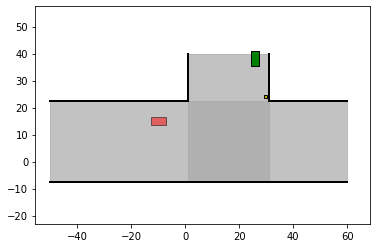

In [3]:
import matplotlib.pyplot as plt
import matplotlib.transforms as tf
from celluloid import Camera
from IPython.display import HTML
import pdb

fig, ax= plt.subplots()
camera = Camera(fig)

for  i in range(Sim.t):
    Sim.draw_intersection(ax, i)
    camera.snap()

animation = camera.animate(repeat = True, repeat_delay = 100)
HTML(animation.to_html5_video())

In [2]:
from intersection_sim import Simulator
from pedestrian_agent import Agent
from mm_mpc_inter import MM_MPC_TI
from uncontrolled_agent import UncontrolledAgent

import numpy as np



ev_noise_std=[0.0001,0.0001]
ev=Agent(role='EV', state=np.array([50, 7.]), cl=3, noise_std=ev_noise_std)
tv_noise_std=[0.1, 0.1]
agents=[Agent(role='TV', cl=4, state=np.array([35, 0.]), noise_std=tv_noise_std) for i in range(1)]
# agents.append(Agent(role='ped', cl=7, state=np.array([0., 4.]), noise_std=tv_noise_std, s_dec = 12))
# agents.append(Agent(role='ped', cl=9, state=np.array([0., 2.]), noise_std=tv_noise_std, s_dec = 12))

tv_n_stds=[v.noise_std for v in agents]
agents.append(ev)
Sim=Simulator(agents, T_FINAL=50)

N=16

# Sim.T+=10
Sim.set_MPC_N(N)

initial_states = [[0.0, 2.0]]
final_states = [[100.0, 4.0]]



cost_func_params = {
    'Q': np.array([[7.0, 0.0, 0.0], [0.0, 7.0, 0.0], [0.0, 0.0, 2.5]]),
    'R': np.array([[.75, 0.0], [0.0, .5]]),
    'P': np.array([[12.5, 0.0], [0.0, 12.5]]),
    'Qc': 8,
    'kappa': 3 
}
mpc_params = {
    'num_agents': 1,
    'dt': 0.2,
    'N' : N,
    'rob_dia': 0.3,
    'v_lim': 8.0,
    'omega_lim': 1.0,
    'total_sim_timestep': 200,
    'obs_sim_timestep': 100,
    'epsilon_o': 0.05,
    'epsilon_r': 0.05,
    'safety_margin': 0.05,
    'goal_tolerence': 0.2, 
    'linearized_ca': True
}
obs_traj = []
static_obs = []

obs = {"static": static_obs, "dynamic": obs_traj}

num_trials = 1
algs = ["MPC"]
vel_var_levels = [0.05, 0.4]
rationality = 0.5
T = 6
y_pos = 3

scenario = "test"
trial = 1
uncontrolled_fleet = UncontrolledAgent(init_state=[(0, 0, -np.pi/2)], dt=mpc_params['dt'], H=mpc_params['dt']*mpc_params['N'], action_variance=0.2)
uncontrolled_fleet_data = uncontrolled_fleet.simulate_diff_drive()

mpc = MM_MPC_TI(initial_states, final_states, cost_func_params, obs, mpc_params, scenario, trial, uncontrolled_fleet, uncontrolled_fleet_data, map=map, feedback=False, robust_horizon=2, ref=None)
# mpc = MM_MPC_TI(initial_states, final_states, cost_func_params, obs, mpc_params, scenario, trial, uncontrolled_agent, uncontrolled_traj)
mpc.simulate(Sim)

0
Infeasible solve
Agent state:  [51.59375  5.75   ]  Agent control:  [[-5.]
 [-5.]
 [-5.]
 [-5.]
 [-5.]
 [-5.]
 [-5.]
 [-5.]
 [-5.]
 [-5.]
 [-5.]
 [-5.]
 [-5.]
 [-5.]
 [-5.]
 [-5.]]
1
Infeasible solve
Agent state:  [52.875  4.5  ]  Agent control:  [[-5.]
 [-5.]
 [-5.]
 [-5.]
 [-5.]
 [-5.]
 [-5.]
 [-5.]
 [-5.]
 [-5.]
 [-5.]
 [-5.]
 [-5.]
 [-5.]
 [-5.]
 [-5.]]
2
Infeasible solve
Agent state:  [53.84375  3.25   ]  Agent control:  [[-5.]
 [-5.]
 [-5.]
 [-5.]
 [-5.]
 [-5.]
 [-5.]
 [-5.]
 [-5.]
 [-5.]
 [-5.]
 [-5.]
 [-5.]
 [-5.]
 [-5.]
 [-5.]]
3
Infeasible solve
Agent state:  [54.5  2. ]  Agent control:  [[-5.]
 [-5.]
 [-5.]
 [-5.]
 [-5.]
 [-5.]
 [-5.]
 [-5.]
 [-5.]
 [-5.]
 [-5.]
 [-5.]
 [-5.]
 [-5.]
 [-5.]
 [-5.]]
4
Infeasible solve
Agent state:  [54.84375  0.75   ]  Agent control:  [[-5.]
 [-5.]
 [-5.]
 [-5.]
 [-5.]
 [-5.]
 [-5.]
 [-5.]
 [-5.]
 [-5.]
 [-5.]
 [-5.]
 [-5.]
 [-5.]
 [-5.]
 [-5.]]
5
Infeasible solve
Agent state:  [54.875 -0.05 ]  Agent control:  [[-5.]
 [-5.]
 [-5.]
 [-5.]
 [-

KeyboardInterrupt: 

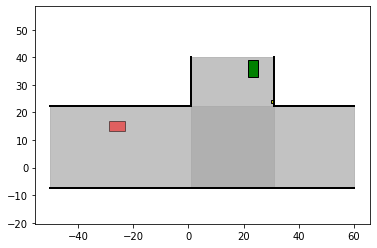

In [5]:
import matplotlib.pyplot as plt
import matplotlib.transforms as tf
from celluloid import Camera
from IPython.display import HTML
import pdb

fig, ax= plt.subplots()
camera = Camera(fig)

for  i in range(Sim.t):
    Sim.draw_intersection(ax, i)
    camera.snap()

animation = camera.animate(repeat = True, repeat_delay = 100)
HTML(animation.to_html5_video())